# Nepal RainTomorrow Prediction

This project predicts whether it will rain tomorrow in 11 Nepal locations. Random Forest, XGBoost, and an Artificial Neural Network are trained on the same chronological split and compared using Accuracy, Precision, Recall, F1, and ROC-AUC.

## 1. Problem

The target is `RainTomorrow`:

- **0 — No Rain**
- **1 — Rain**

The final model should identify rainy days accurately while keeping false rain warnings under control.

In [70]:
# Import the required libraries
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Use the same seed across the models
SEED = 42

# Apply a clean style to all graphs
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Historical Nepal weather data

### Data source

The raw weather data was collected from the **[Open-Meteo Historical Weather Archive](https://open-meteo.com/en/docs/historical-weather-api)** for 11 locations in Nepal. The collected observations cover 2010–2026 and were saved as `Nepal_Weather_2010_2026.csv`.

This notebook loads the saved CSV directly; it does not download the data again.

In [71]:
# Load the saved Nepal weather dataset
data = pd.read_csv("Nepal_Weather_2010_2026.csv")
data.head()

,Date,MaxTemp,MinTemp,Rainfall,Sunshine,Evaporation,WindGustSpeed,WindGustDir,Temp9am,Humidity9am,Pressure9am,Cloud9am,WindSpeed9am,WindDir9am,Temp3pm,Humidity3pm,Pressure3pm,Cloud3pm,WindSpeed3pm,WindDir3pm,Location,RainToday,RainTomorrow
0,2010-01-01,16.1,7.2,0.0,10.166575,2.20,20.2,217,12.2,64,1017.9,15,2.3,162,15.7,57,1014.9,3,5.1,231,Kathmandu,No,No
1,2010-01-02,17.5,7.6,0.0,10.237128,2.45,23.0,248,14.4,55,1020.1,1,1.6,153,16.7,45,1017.0,3,4.7,238,Kathmandu,No,No
2,2010-01-03,19.2,9.3,0.0,9.984028,2.55,21.6,220,15.5,41,1018.8,38,2.3,219,18.3,40,1013.6,94,5.4,228,Kathmandu,No,No
3,2010-01-04,19.8,9.3,0.2,10.217242,2.43,31.7,236,15.5,62,1014.0,10,4.0,280,18.3,55,1008.6,8,7.9,246,Kathmandu,No,No
4,2010-01-05,15.8,8.8,0.1,10.127119,2.03,22.0,180,13.1,65,1014.3,18,4.0,153,15.2,63,1011.0,12,5.6,220,Kathmandu,No,No


In [72]:
# Inspect the columns, data types, and missing values
print("Columns:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes.rename("Data type").to_frame())

print("\nMissing values:")
display(data.isnull().sum().sort_values(ascending=False).rename("Missing").to_frame())

print("Dataset shape:", data.shape)
print("Duplicate rows:", data.duplicated().sum())

Columns:
['Date', 'MaxTemp', 'MinTemp', 'Rainfall', 'Sunshine', 'Evaporation', 'WindGustSpeed', 'WindGustDir', 'Temp9am', 'Humidity9am', 'Pressure9am', 'Cloud9am', 'WindSpeed9am', 'WindDir9am', 'Temp3pm', 'Humidity3pm', 'Pressure3pm', 'Cloud3pm', 'WindSpeed3pm', 'WindDir3pm', 'Location', 'RainToday', 'RainTomorrow']

Data types:


,Data type
Date,object
MaxTemp,float64
MinTemp,float64
Rainfall,float64
Sunshine,float64
Evaporation,float64
WindGustSpeed,float64
WindGustDir,int64
Temp9am,float64
Humidity9am,int64



Missing values:


,Missing
Date,0
WindSpeed9am,0
RainToday,0
Location,0
WindDir3pm,0
WindSpeed3pm,0
Cloud3pm,0
Pressure3pm,0
Humidity3pm,0
Temp3pm,0


Dataset shape: (66946, 23)
Duplicate rows: 0


## 3. Data preparation and RainTomorrow target

In [73]:
# Convert the date and rain labels into model-ready values
df = data.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.drop_duplicates().sort_values(["Date", "Location"]).reset_index(drop=True)

rain_map = {"No": 0, "Yes": 1, 0: 0, 1: 1}
df["RainToday"] = df["RainToday"].map(rain_map)
df["RainTomorrow"] = df["RainTomorrow"].map(rain_map)

if df[["RainToday", "RainTomorrow"]].isnull().any().any():
    raise ValueError("RainToday or RainTomorrow contains an unexpected value.")

df[["RainToday", "RainTomorrow"]] = df[["RainToday", "RainTomorrow"]].astype(int)

print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Locations:", df["Location"].nunique())
display(df.head())

Date range: 2010-01-01 to 2026-08-30
Locations: 11


,Date,MaxTemp,MinTemp,Rainfall,Sunshine,Evaporation,WindGustSpeed,WindGustDir,Temp9am,Humidity9am,Pressure9am,Cloud9am,WindSpeed9am,WindDir9am,Temp3pm,Humidity3pm,Pressure3pm,Cloud3pm,WindSpeed3pm,WindDir3pm,Location,RainToday,RainTomorrow
0,2010-01-01,19.0,9.1,0.0,10.240333,2.27,18.4,167,14.9,70,1019.0,6,3.6,180,18.7,55,1015.5,2,5.4,217,Bharatpur,0,0
1,2010-01-01,21.0,10.4,0.0,10.047764,2.60,19.8,273,16.4,68,1018.2,1,6.1,267,20.8,51,1015.1,0,4.0,207,Biratnagar,0,0
2,2010-01-01,17.6,5.3,0.0,9.831758,2.08,22.7,99,13.1,80,1018.4,26,3.6,84,17.3,65,1015.8,27,4.7,189,Dhangadhi,0,0
3,2010-01-01,18.3,7.9,0.0,10.133411,2.20,20.9,240,14.7,68,1018.5,6,2.5,180,17.8,60,1015.4,1,6.1,225,Hetauda,0,0
4,2010-01-01,20.1,9.5,0.0,10.073944,2.56,22.3,277,15.5,69,1019.0,5,5.0,270,20.0,49,1015.6,0,8.7,253,Janakpur,0,0


### Target distribution

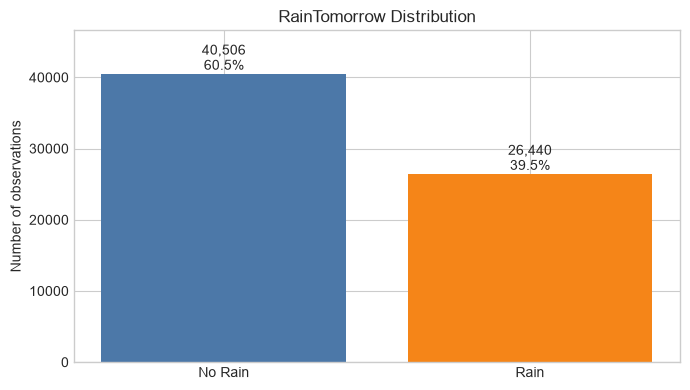

In [74]:
# Plot the number of rainy and non-rainy target rows
target_counts = df["RainTomorrow"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["No Rain", "Rain"], target_counts.values, color=["#4C78A8", "#F58518"])
ax.set_title("RainTomorrow Distribution")
ax.set_ylabel("Number of observations")

for bar, count in zip(bars, target_counts.values):
    percent = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, count, f"{count:,}\n{percent:.1f}%", ha="center", va="bottom")

ax.set_ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()

### Weather-feature distributions

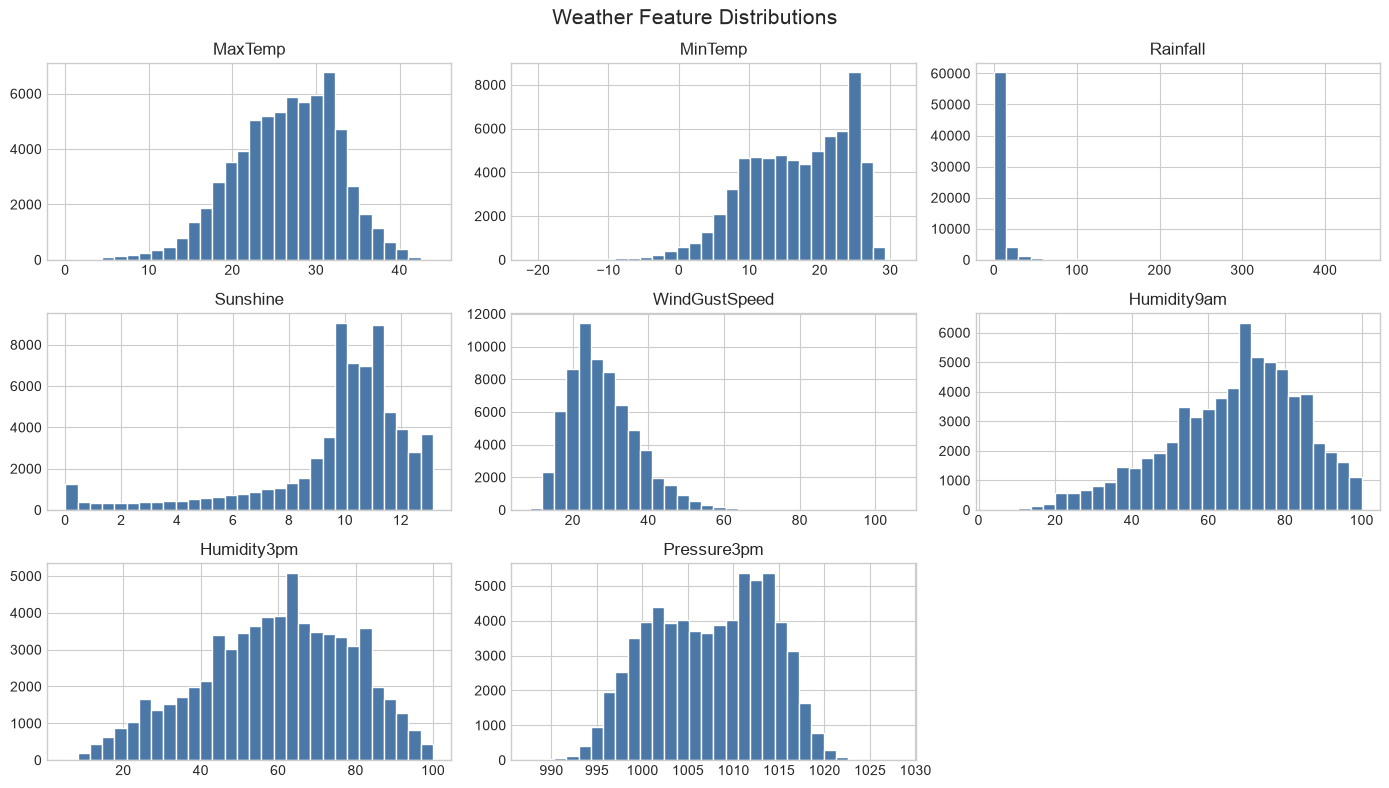

In [75]:
# Plot the distributions of important weather features
distribution_cols = [
    "MaxTemp", "MinTemp", "Rainfall", "Sunshine",
    "WindGustSpeed", "Humidity9am", "Humidity3pm", "Pressure3pm",
]

df[distribution_cols].hist(
    bins=30,
    figsize=(14, 8),
    color="#4C78A8",
    edgecolor="white",
)
plt.suptitle("Weather Feature Distributions", fontsize=15)
plt.tight_layout()
plt.show()

### Boxen plot and outliers

The numerical weather features use different units, so they are standardized only for this visualization. The boxen plot shows the center, spread, tails, and possible outliers of every numerical weather feature on one graph. The original values are retained for model training.

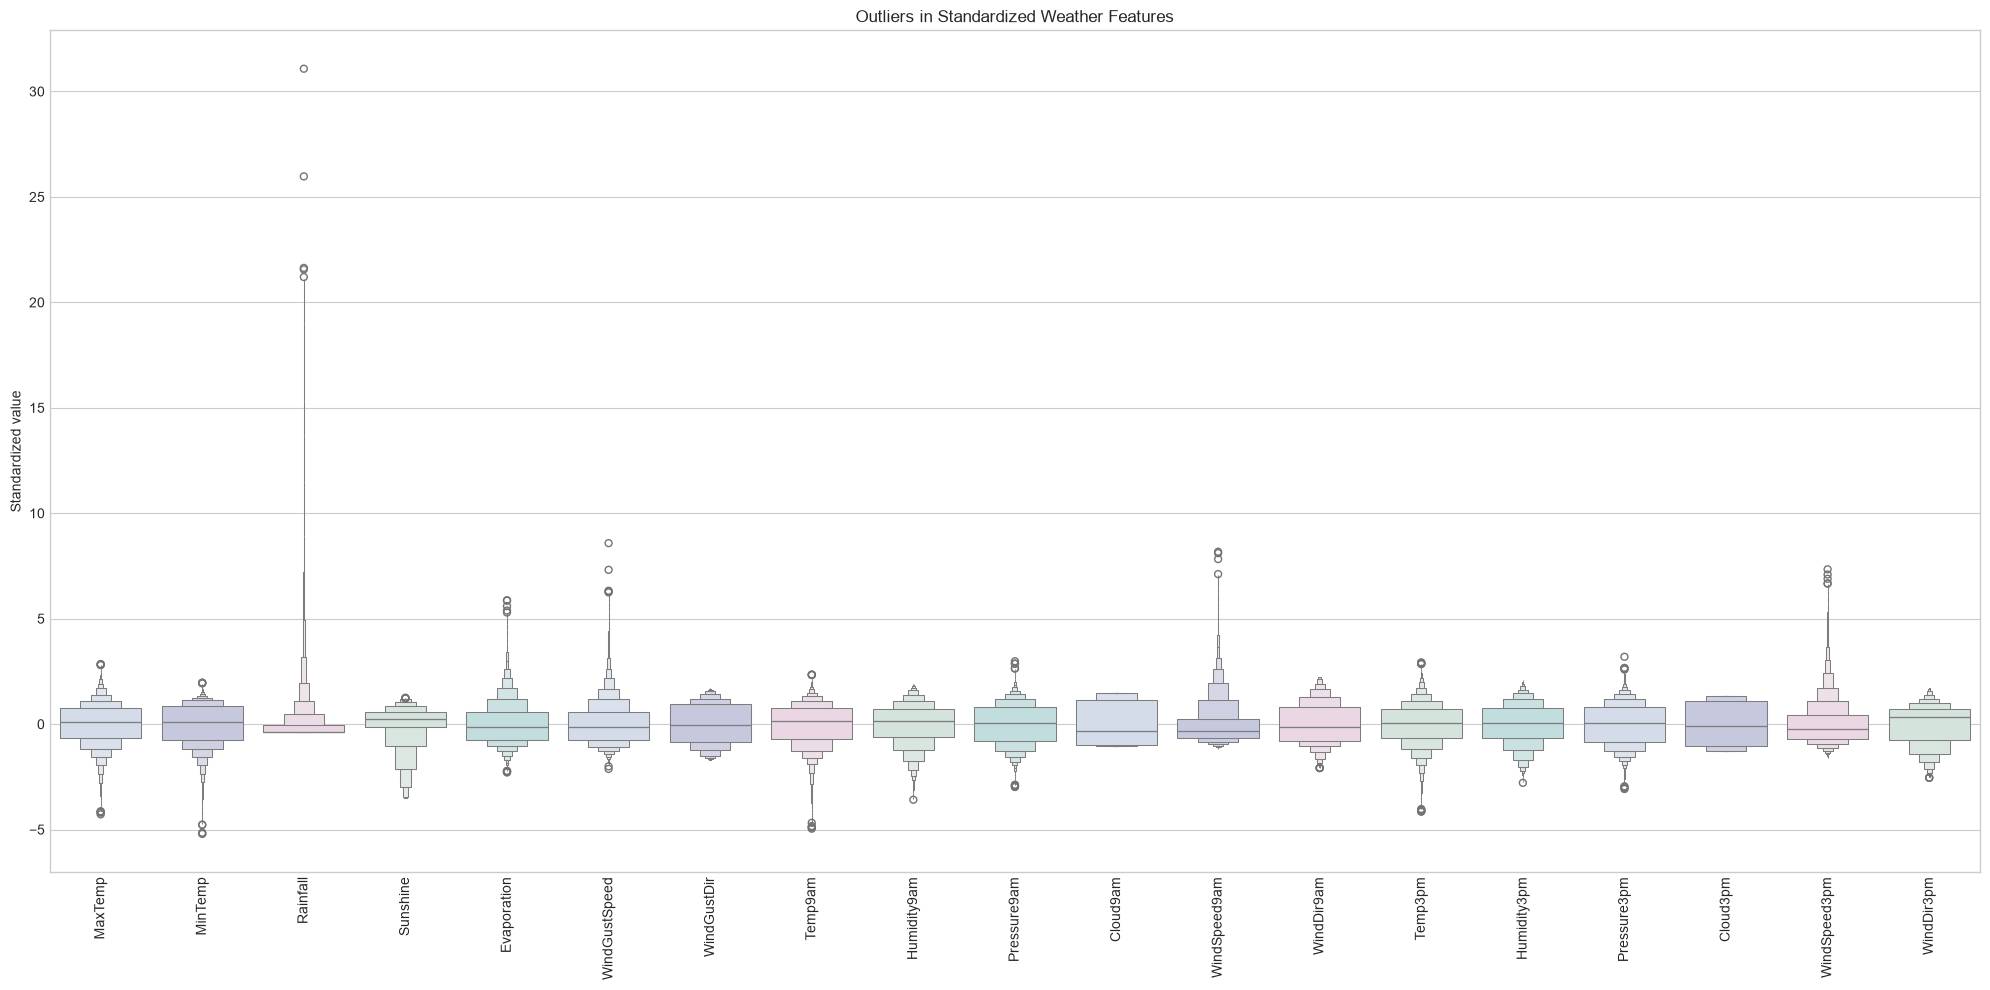

In [76]:
# Detect outliers in the scaled numerical features
boxplot_cols = [
    column for column in df.select_dtypes(include=np.number).columns
    if column not in ["RainToday", "RainTomorrow"]
]

boxplot_data = df[boxplot_cols].copy()
boxplot_data = boxplot_data.fillna(boxplot_data.median())
scaled_features = pd.DataFrame(
    StandardScaler().fit_transform(boxplot_data),
    columns=boxplot_cols,
)

colours = ["#D0DBEE", "#C2C4E2", "#EED4E5", "#D1E6DC", "#BDE2E2"]
palette = {
    column: colours[index % len(colours)]
    for index, column in enumerate(scaled_features.columns)
}

plt.figure(figsize=(20, 10))
sns.boxenplot(data=scaled_features, palette=palette)
plt.title("Outliers in Standardized Weather Features")
plt.ylabel("Standardized value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Correlation heatmap

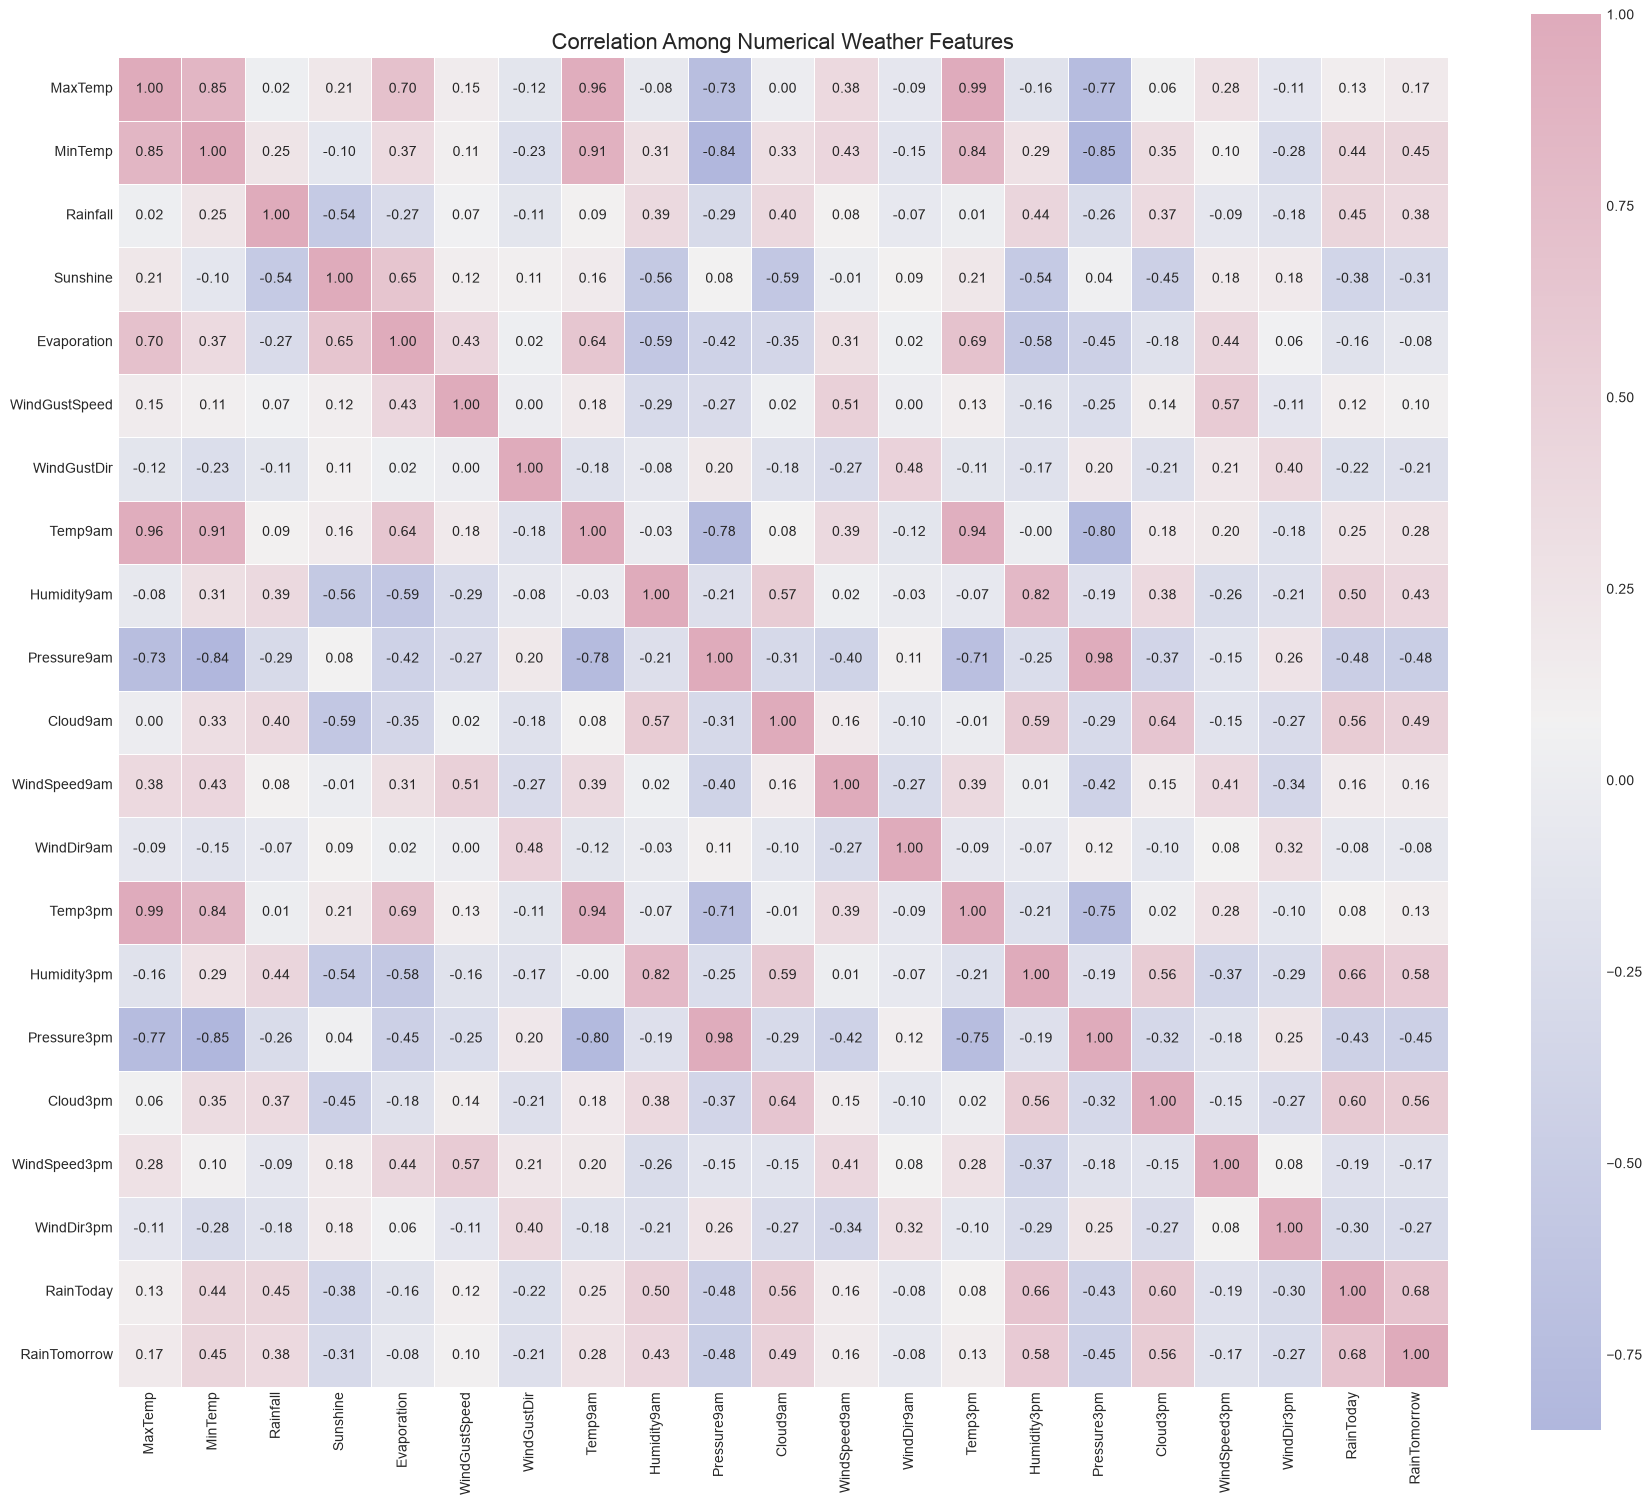

,Correlation with RainTomorrow
RainToday,0.677494
Humidity3pm,0.576380
Cloud3pm,0.561154
Cloud9am,0.493528
Pressure9am,-0.484886
Pressure3pm,-0.451538
MinTemp,0.447411
Humidity9am,0.425425
Rainfall,0.381132
Sunshine,-0.306942


In [77]:
# Calculate and plot correlations between numerical features
correlation = df.select_dtypes(include=np.number).corr()
cmap = sns.diverging_palette(260, -10, s=50, l=75, n=6, as_cmap=True)

plt.figure(figsize=(18, 18))
sns.heatmap(
    correlation,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Among Numerical Weather Features", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(
    correlation["RainTomorrow"]
    .drop("RainTomorrow")
    .sort_values(key=abs, ascending=False)
    .rename("Correlation with RainTomorrow")
    .head(10)
    .to_frame()
)

### Rain by month

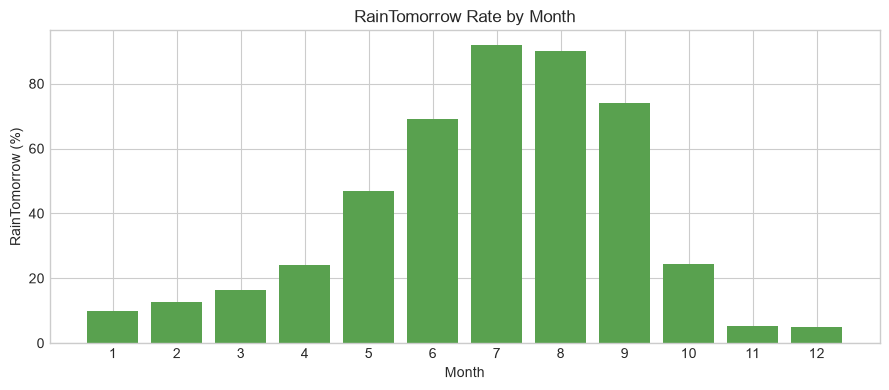

In [78]:
# Compare the percentage of rainy target days by month
monthly_rain = df.groupby(df["Date"].dt.month)["RainTomorrow"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly_rain.index, monthly_rain.values, color="#59A14F")
ax.set_title("RainTomorrow Rate by Month")
ax.set_xlabel("Month")
ax.set_ylabel("RainTomorrow (%)")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Date features

In [79]:
# Extract useful calendar features from the date
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

display(df[["Date", "Year", "Month", "Day", "DayOfWeek"]].head())

,Date,Year,Month,Day,DayOfWeek
0,2010-01-01,2010,1,1,4
1,2010-01-01,2010,1,1,4
2,2010-01-01,2010,1,1,4
3,2010-01-01,2010,1,1,4
4,2010-01-01,2010,1,1,4


## 4. Chronological train/test split

Earlier dates are used for training and later dates for testing. The cutoff is the 80th percentile of unique dates. One boundary day is left out because each row predicts the following day.

In [80]:
# Separate the model features, target, and dates
X = df.drop(columns=["Date", "RainTomorrow"])
y = df["RainTomorrow"]
dates = df["Date"]

unique_dates = np.sort(dates.unique())
cutoff_date = pd.Timestamp(unique_dates[int(len(unique_dates) * 0.80)])

train_mask = dates + pd.Timedelta(days=1) < cutoff_date
test_mask = dates >= cutoff_date

X_train = X.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)
y_train = y.loc[train_mask].reset_index(drop=True)
y_test = y.loc[test_mask].reset_index(drop=True)
train_dates = dates.loc[train_mask].reset_index(drop=True)
test_dates = dates.loc[test_mask].reset_index(drop=True)

print("Cutoff date:", cutoff_date.date())
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training period:", train_dates.min().date(), "to", train_dates.max().date())
print("Testing period:", test_dates.min().date(), "to", test_dates.max().date())

Cutoff date: 2023-05-01
Training shape: (53537, 25)
Testing shape: (13398, 25)
Training period: 2010-01-01 to 2023-04-29
Testing period: 2023-05-01 to 2026-08-30


### Preprocessing

In [81]:
# Define preprocessing for numerical and location features
categorical_cols = ["Location"]
numeric_cols = [column for column in X_train.columns if column not in categorical_cols]


def one_hot_encoder():
    options = {"handle_unknown": "ignore"}
    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
        options["sparse_output"] = False
    else:
        options["sparse"] = False
    return OneHotEncoder(**options)


def tree_preprocessor():
    return ColumnTransformer([
        ("numeric", SimpleImputer(strategy="median"), numeric_cols),
        ("location", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot_encoder()),
        ]), categorical_cols),
    ])


def ann_preprocessor():
    return ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("location", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot_encoder()),
        ]), categorical_cols),
    ])

## 5. Random Forest

Random Forest combines many decision trees and takes their majority vote. It is a strong baseline for weather data because it can learn nonlinear relationships and interactions without requiring numerical-feature scaling.

In [82]:
# Build and train the Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

## 6. XGBoost

XGBoost builds trees sequentially, with each new tree focusing on errors made by the earlier trees. It often performs especially well on structured tabular data and is trained here with the same features and chronological split as Random Forest.

In [83]:
# Build and train the XGBoost pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor()),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        eval_metric="logloss",
        n_jobs=-1,
    )),
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

## 7. Artificial Neural Network

The ANN uses connected layers of neurons to learn complex patterns in the weather features. Numerical features are standardized before training, and EarlyStopping restores the weights from the epoch with the lowest validation loss to reduce overfitting.

In [84]:
# Create an earlier training period and a later validation period
train_unique_dates = np.sort(train_dates.unique())
validation_date = pd.Timestamp(train_unique_dates[int(len(train_unique_dates) * 0.80)])

ann_train_mask = train_dates + pd.Timedelta(days=1) < validation_date
ann_validation_mask = train_dates >= validation_date

X_ann_train = X_train.loc[ann_train_mask].reset_index(drop=True)
y_ann_train = y_train.loc[ann_train_mask].reset_index(drop=True)
X_ann_validation = X_train.loc[ann_validation_mask].reset_index(drop=True)
y_ann_validation = y_train.loc[ann_validation_mask].reset_index(drop=True)

ann_prep = ann_preprocessor()
X_ann_train_ready = ann_prep.fit_transform(X_ann_train).astype("float32")
X_ann_validation_ready = ann_prep.transform(X_ann_validation).astype("float32")

print("ANN training shape:", X_ann_train_ready.shape)
print("ANN validation shape:", X_ann_validation_ready.shape)

ANN training shape: (42812, 35)
ANN validation shape: (10714, 35)


In [85]:
# Define the ANN architecture
def build_ann(number_of_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(number_of_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


# Build the ANN and stop when validation loss stops improving
ann_tuning_model = build_ann(X_ann_train_ready.shape[1])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = ann_tuning_model.fit(
    X_ann_train_ready,
    y_ann_train,
    validation_data=(X_ann_validation_ready, y_ann_validation),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=2,
)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
print("Best epoch:", best_epoch)

Epoch 1/100
1338/1338 - 1s - 823us/step - accuracy: 0.8452 - loss: 0.3725 - val_accuracy: 0.8735 - val_loss: 0.3196
Epoch 2/100
1338/1338 - 0s - 331us/step - accuracy: 0.8607 - loss: 0.3340 - val_accuracy: 0.8761 - val_loss: 0.3137
Epoch 3/100
1338/1338 - 0s - 328us/step - accuracy: 0.8638 - loss: 0.3280 - val_accuracy: 0.8766 - val_loss: 0.3093
Epoch 4/100
1338/1338 - 0s - 329us/step - accuracy: 0.8646 - loss: 0.3237 - val_accuracy: 0.8785 - val_loss: 0.3112
Epoch 5/100
1338/1338 - 0s - 323us/step - accuracy: 0.8649 - loss: 0.3201 - val_accuracy: 0.8762 - val_loss: 0.3194
Epoch 6/100
1338/1338 - 0s - 330us/step - accuracy: 0.8656 - loss: 0.3182 - val_accuracy: 0.8727 - val_loss: 0.3156
Epoch 7/100
1338/1338 - 0s - 324us/step - accuracy: 0.8685 - loss: 0.3157 - val_accuracy: 0.8757 - val_loss: 0.3130
Epoch 8/100
1338/1338 - 0s - 323us/step - accuracy: 0.8676 - loss: 0.3143 - val_accuracy: 0.8747 - val_loss: 0.3191
Epoch 9/100
1338/1338 - 0s - 323us/step - accuracy: 0.8684 - loss: 0.312

### ANN training history

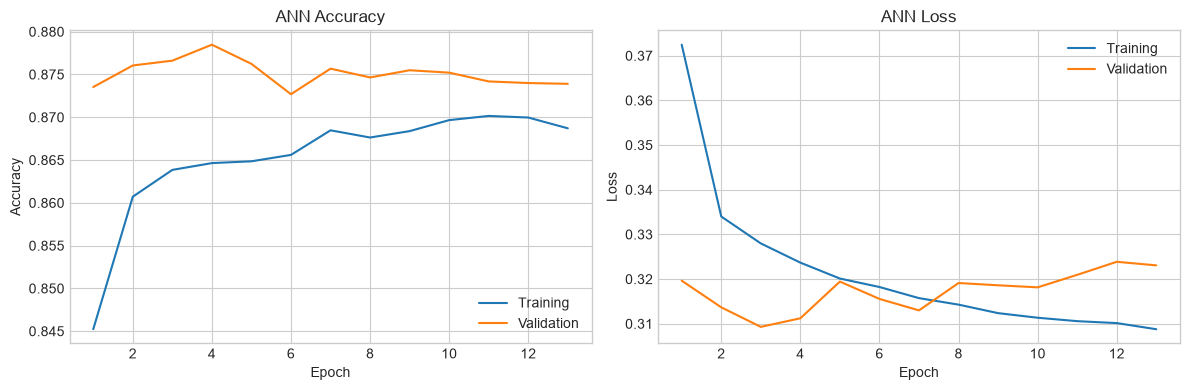

In [86]:
# Plot ANN training and validation performance
epochs = range(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].set_title("ANN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].set_title("ANN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [87]:
# Predict the untouched test set with the trained ANN
X_test_ann = ann_prep.transform(X_test).astype("float32")
ann_model = ann_tuning_model

y_prob_ann = ann_model.predict(X_test_ann, verbose=0).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

## 8. Compare all models

All three models are evaluated on the same future test period.

- **Accuracy:** overall proportion of correct predictions
- **Precision:** proportion of rain predictions that were correct
- **Recall:** proportion of actual rainy days detected
- **F1:** balance between precision and recall
- **ROC-AUC:** ability to separate rainy and non-rainy days across probability thresholds

In [88]:
# Calculate the five evaluation metrics for each model
def model_scores(y_true, y_pred, y_probability):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_probability),
    }


comparison = pd.DataFrame({
    "Random Forest": model_scores(y_test, y_pred_rf, y_prob_rf),
    "XGBoost": model_scores(y_test, y_pred_xgb, y_prob_xgb),
    "ANN": model_scores(y_test, y_pred_ann, y_prob_ann),
}).T

def score_table(frame, highlight=True):
    styled = (
        frame.style
        .format("{:.4f}")
        .set_properties(**{
            "background-color": "#F8FAFC",
            "color": "#172033",
            "border": "1px solid #D7DEE8",
            "text-align": "center",
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#214F77"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", "1px solid #D7DEE8"),
                ],
            },
        ])
    )

    if highlight:
        styled = styled.highlight_max(
            axis=0,
            props="background-color: #1F7A4D; color: white; font-weight: bold;",
        )
    return styled


display(score_table(comparison))

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.8599,0.8061,0.8343,0.8200,0.9295
XGBoost,0.8603,0.8034,0.8404,0.8214,0.9307
ANN,0.8511,0.7690,0.8730,0.8177,0.9257


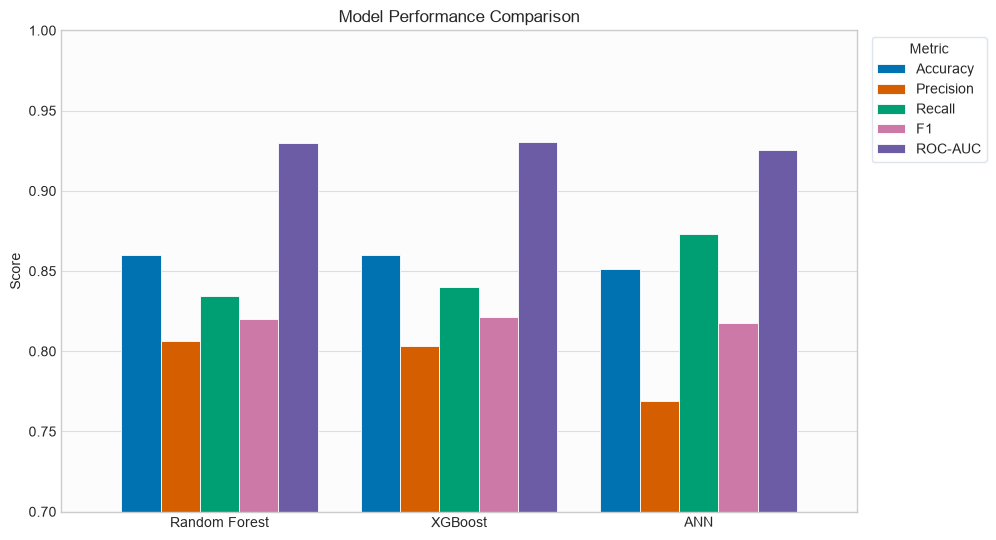

In [89]:
# Plot all model metrics with distinct colors
metric_colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#6B5CA5"]

ax = comparison.plot(
    kind="bar",
    figsize=(12, 5.5),
    width=0.82,
    color=metric_colors,
    edgecolor="white",
    linewidth=0.6,
)
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0.70, 1.0)
ax.set_xticklabels(comparison.index, rotation=0)
ax.legend(
    title="Metric",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    facecolor="white",
    edgecolor="#D7DEE8",
)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", color="#D7DEE8", linewidth=0.8)
ax.set_facecolor("#FCFCFD")
ax.figure.set_facecolor("white")
plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

### Confusion matrices

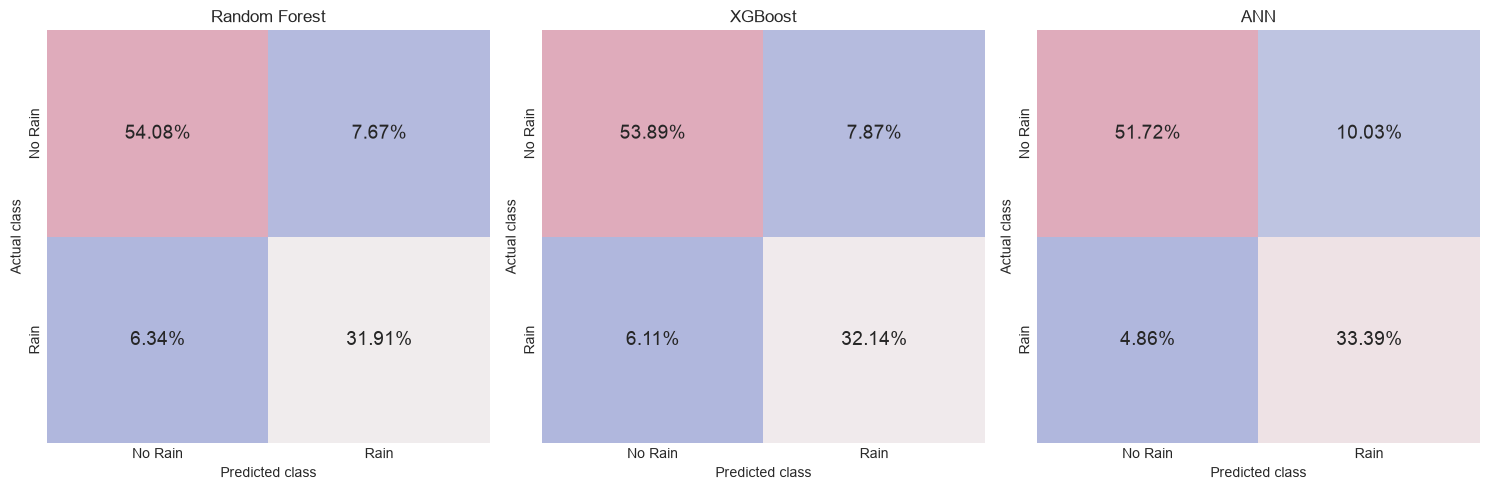

In [90]:
# Display normalized confusion matrices for all models
confusion_cmap = sns.diverging_palette(260, -10, s=50, l=75, n=5, as_cmap=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name, predictions in zip(
    axes,
    ["Random Forest", "XGBoost", "ANN"],
    [y_pred_rf, y_pred_xgb, y_pred_ann],
):
    matrix = confusion_matrix(y_test, predictions)
    normalized_matrix = matrix / np.sum(matrix)

    sns.heatmap(
        normalized_matrix,
        cmap=confusion_cmap,
        annot=True,
        fmt=".2%",
        annot_kws={"size": 14},
        xticklabels=["No Rain", "Rain"],
        yticklabels=["No Rain", "Rain"],
        cbar=False,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

### ROC curves

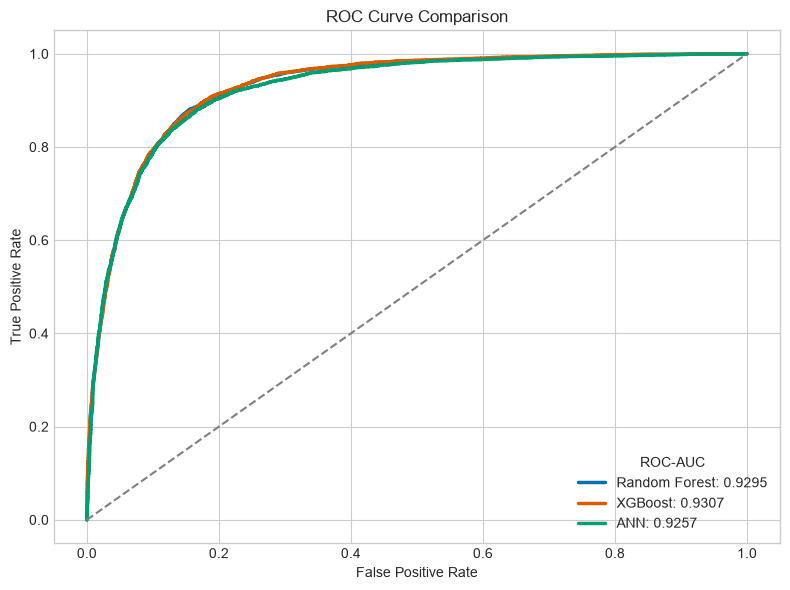

In [91]:
# Plot the ROC curves on the same graph
fig, ax = plt.subplots(figsize=(8, 6))

for name, probabilities, color in [
    ("Random Forest", y_prob_rf, "#0072B2"),
    ("XGBoost", y_prob_xgb, "#D55E00"),
    ("ANN", y_prob_ann, "#009E73"),
]:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    ax.plot(false_positive_rate, true_positive_rate, color=color, linewidth=2.5, label=f"{name}: {auc:.4f}")

ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(title="ROC-AUC", loc="lower right")
plt.tight_layout()
plt.show()

## 9. Select XGBoost

XGBoost is selected when it achieves the strongest ROC-AUC on the future test period. Recall remains important for understanding how many rainy days each model catches, but ROC-AUC provides the main overall comparison of probability-based discrimination.

In [92]:
# Select the model with the highest ROC-AUC
selected_model = comparison["ROC-AUC"].idxmax()
print("Best model by ROC-AUC:", selected_model)
display(score_table(comparison.loc[[selected_model]], highlight=False))

if selected_model == "XGBoost":
    print("XGBoost is selected as the final model.")
else:
    print("The new run should be reviewed because it did not reproduce XGBoost as the highest ROC-AUC model.")

Best model by ROC-AUC: XGBoost


,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost,0.8603,0.8034,0.8404,0.8214,0.9307


XGBoost is selected as the final model.


## 10. XGBoost feature importance

Feature importance shows which inputs contributed most to the XGBoost decision trees. A higher score means the feature was used more strongly by the model; it does not prove that the feature directly causes rain.

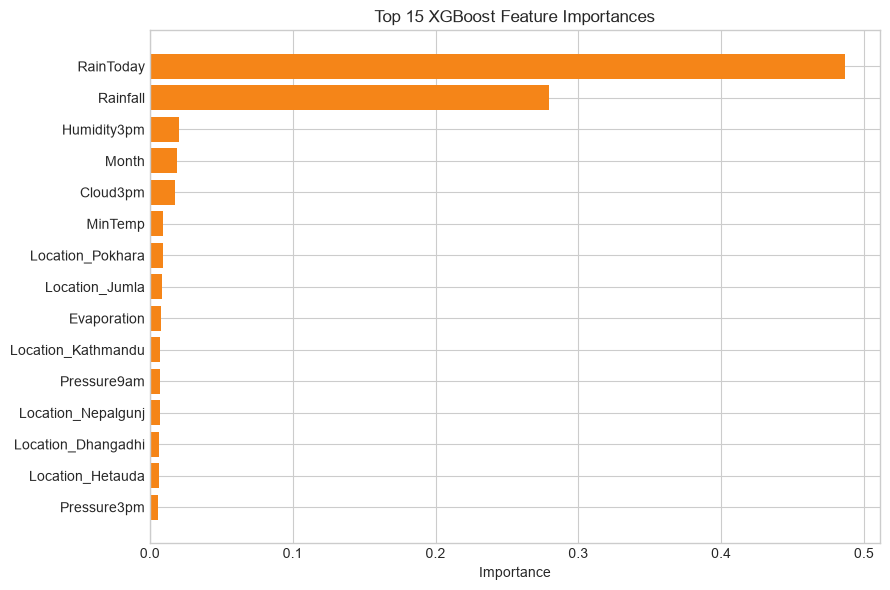

,Feature,Importance
0,RainToday,0.486884
1,Rainfall,0.279472
2,Humidity3pm,0.020202
3,Month,0.019277
4,Cloud3pm,0.017321
5,MinTemp,0.009360
6,Location_Pokhara,0.009285
7,Location_Jumla,0.008453
8,Evaporation,0.007559
9,Location_Kathmandu,0.007366


In [93]:
# Extract and plot the most important XGBoost features
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = xgb_pipeline.named_steps["model"].feature_importances_

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=False)

importance["Feature"] = (
    importance["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("location__", "", regex=False)
    .str.replace("onehot__", "", regex=False)
)

top_features = importance.head(15).sort_values("Importance")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features["Feature"], top_features["Importance"], color="#F58518")
ax.set_title("Top 15 XGBoost Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

display(importance.head(15).reset_index(drop=True))

## 11. Final prediction example

In [94]:
# Predict one historical row from the test period
sample = X_test.iloc[[0]]
predicted_class = int(xgb_pipeline.predict(sample)[0])
rain_probability = float(xgb_pipeline.predict_proba(sample)[0, 1])
actual_class = int(y_test.iloc[0])
labels = {0: "No Rain", 1: "Rain"}

prediction_example = pd.DataFrame([{
    "Date": test_dates.iloc[0].strftime("%Y-%m-%d"),
    "Location": sample["Location"].iloc[0],
    "Predicted class": labels[predicted_class],
    "Actual class": labels[actual_class],
    "Rain probability": rain_probability,
}])

display(prediction_example.style.format({"Rain probability": "{:.1%}"}))

,Date,Location,Predicted class,Actual class,Rain probability
0,2023-05-01,Bharatpur,Rain,Rain,80.8%


## Conclusion

The project concludes by:

- Testing every model on the later chronological test period
- Comparing Accuracy, Precision, Recall, F1, and ROC-AUC
- Evaluating the confusion matrices and ROC curves
- Selecting **XGBoost** for the strongest overall test performance
- Using feature importance to explain the final model

The ANN detects the largest share of rainy days, while XGBoost provides the best overall balance and the highest ROC-AUC in the verified run.